In [1]:
import os

import pandas as pd
import pytorch_lightning as pl
import seaborn as sn
import torch
import torchvision
from IPython.display import display
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

from perspic import analyzer
from perspic import logarithmic_windows
from examples.models import BatchNormMLP, ClassificationModule, WideResNet
from torchvision.models import VisionTransformer
from examples.models.utils import print_model_info

from pytorch_lightning.profilers import SimpleProfiler

import matplotlib.pyplot as plt

pl.seed_everything(7)

PATH_DATASETS = os.environ.get("PATH_DATASETS", ".")
BATCH_SIZE = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = int(os.cpu_count() / 2)

Seed set to 7


In [2]:
# CIFAR10 mean and std
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])

# Load datasets
# We instantiate the dataset twice to apply different transforms to train and val splits
train_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=train_transform)
val_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=test_transform)
test_set = CIFAR10(PATH_DATASETS, train=False, download=True, transform=test_transform)

# Split train/val (45k/5k)
# We use the same seed to ensure the split indices are identical for both dataset instances
generator = torch.Generator().manual_seed(42)
train_set, _ = random_split(train_dataset_full, [45000, 5000], generator=generator)
_, val_set = random_split(val_dataset_full, [45000, 5000], generator=generator)

# DataLoaders
# We set drop_last=True to avoid spikes in gradient norms caused by smaller last batches
train_dataloader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_dataloader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
test_dataloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)

In [3]:
# Define model
model_vit_large = VisionTransformer(
    image_size=32,
    patch_size=4,
    num_layers=6,
    num_heads=8,
    hidden_dim=256,
    mlp_dim=512,
    num_classes=10,
)

In [4]:
# Example usage of adding a scheduler

NUM_EPOCHS = 5
NUM_STEPS = (len(train_set) // BATCH_SIZE) * NUM_EPOCHS

# Create logarithmic schedule for sparse analysis at log-spaced intervals
schedule = logarithmic_windows(
    max_steps=50000,      # Max step to cover
    points_per_decade=3,  # Windows per 10x increase
    base_window=20,       # Window size
)

schedule

LogarithmicWindowSchedule(num_windows=15, total_steps=222)

In [5]:
# Wrap the model with the analyzer
# This adds the capability to track additional metrics (like gradients) during training
vit_model = analyzer(
    lightning_module=ClassificationModule, 
    sample_wise_engine="opacus",
    opacus_strict=True, 
    analysis_schedule=schedule,  # Use logarithmic schedule
    model=model_vit_large,
    lr=0.001,
    optimizer_name="adamw",
    weight_decay=0.1,
    scheduler_name="cosine",
    disable_analyzer=False,  # Enable analysis
)
# # Overwrite to skip analysis for faster training
# vit_model = ClassificationModule(
#     model=model_vit_large, 
#     lr=0.001,
#     optimizer_name="adamw",
#     weight_decay=0.1,
#     scheduler_name="cosine",
# )

# Define the Trainer
trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
    # gradient_clip_val=1.0,  # Gradient clipping stabilizes ViT training
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [6]:
# Train and test the model

trainer.fit(vit_model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer.test(vit_model, dataloaders=test_dataloader)

You are using a CUDA device ('NVIDIA GeForce RTX 3090 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 3.2 M  | train
----------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.781    Total estimated model params size (MB)
80        Modules in train mode
0         Modules in eval mode

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 3.2 M  | train
-------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

/data/knikolaou/software/miniconda3/envs/lightning/lib/python3.11/site-packages/torch/autograd/graph.py:823: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_efficient_attention_backward. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:81.)


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5858373641967773
        test_loss           1.1369619369506836
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.1369619369506836, 'test_acc': 0.5858373641967773}]

In [7]:
# --- Helper Functions for Plotting Windowed Analysis ---

ANALYSIS_METRICS = {"chi_net", "chi_loss", "loss", "grad_norm_squared", 
                    "cross_loss", "cross_grad_dot_product",
                    "coupling", "window_id", "window_center"}

def plot_metric_standard(ax, data, column, label, color, alpha=0.35, ema_span=50, negate=False):
    """
    Plots raw data with transparency and an Exponential Moving Average (EMA) overlay.
    Used for standard metrics like loss and accuracy that are logged every step.
    """
    step_col = "analysis_step" if column in ANALYSIS_METRICS else "step"
    if step_col == "analysis_step" and step_col not in data.columns:
        step_col = "step"
    
    subset = data[[column, step_col]].dropna().sort_values(step_col)
    steps = subset[step_col]
    if len(steps) > 0 and steps.min() == 0:
        steps = steps + 1
        
    values = subset[column].values
    if negate:
        values = -values
        
    series = pd.Series(values, index=steps)
    
    if len(series) > 50: 
        ax.plot(series.index, series.values, color=color, alpha=alpha, linewidth=1, label=f"{label} (Raw)")
        ema = series.ewm(span=ema_span).mean()
        ax.plot(series.index, ema.values, color=color, label=f"{label} (EMA)", linewidth=2)
    else:
        ax.plot(series.index, series.values, color=color, label=label, marker='o', linestyle='--', linewidth=2)


def plot_metric_windowed(ax, data, column, label, color, ema_span=50, negate=False, alpha=0.35):
    """
    Plots windowed analysis metrics. 
    - First window: EMA smoothing (raw + EMA line)
    - Subsequent windows: Full raw data with alpha + scatter plot of window averages
    """
    if column not in data.columns or "window_id" not in data.columns:
        return
    
    step_col = "analysis_step" if "analysis_step" in data.columns else "step"
    
    # Get data with window info
    subset = data[[column, step_col, "window_id", "window_center"]].dropna().sort_values(step_col)
    
    if len(subset) == 0:
        return
    
    values = subset[column].values.copy()
    if negate:
        values = -values
    subset = subset.copy()
    subset["plot_values"] = values
    
    # Get unique windows sorted by their center
    windows = subset.groupby("window_id").agg({
        "window_center": "first",
        "plot_values": ["mean", "std"],
        step_col: ["min", "max"]
    }).reset_index()
    windows.columns = ["window_id", "center", "mean", "std", "step_min", "step_max"]
    # Calculate actual plot positions as the midpoint of the window steps
    windows["plot_center"] = (windows["step_min"] + windows["step_max"]) / 2
    windows = windows.sort_values("center")
    
    if len(windows) == 0:
        return
    
    # First window: plot with EMA
    first_window_id = windows.iloc[0]["window_id"]
    first_window_data = subset[subset["window_id"] == first_window_id].sort_values(step_col)
    
    if len(first_window_data) > 0:
        steps_first = first_window_data[step_col].values
        if steps_first.min() == 0:
            steps_first = steps_first + 1
        values_first = first_window_data["plot_values"].values
        series_first = pd.Series(values_first, index=steps_first)
        
        # Plot raw data for first window
        ax.plot(series_first.index, series_first.values, color=color, alpha=alpha, linewidth=1)
        # Plot EMA for first window
        if len(series_first) > 3:
            ema = series_first.ewm(span=min(ema_span, len(series_first))).mean()
            ax.plot(series_first.index, ema.values, color=color, linewidth=2, label=f"{label}")
        else:
            ax.plot(series_first.index, series_first.values, color=color, linewidth=2, label=f"{label}")
    
    # Subsequent windows: plot full raw data with alpha + scatter of window averages
    if len(windows) > 1:
        other_window_ids = windows.iloc[1:]["window_id"].values
        other_window_data = subset[subset["window_id"].isin(other_window_ids)].sort_values(step_col)
        
        if len(other_window_data) > 0:
            steps_other = other_window_data[step_col].values
            if steps_other.min() == 0:
                steps_other = steps_other + 1
            values_other = other_window_data["plot_values"].values
            
            # Plot full raw data with alpha transparency
            ax.plot(steps_other, values_other, color=color, alpha=alpha, linewidth=1)
        
        # Scatter plot of window averages
        other_windows = windows.iloc[1:]
        centers = other_windows["plot_center"].values
        means = other_windows["mean"].values
        
        ax.scatter(centers, means, color=color, s=50, zorder=5)


def configure_axis(ax, title, ylabel, xlabel="Step (log scale)", xscale="log", yscale="linear"):
    """Configures the appearance of a subplot axis."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.grid(True, alpha=0.3, which="both")
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")


def plot_scheduler_metrics(metrics, title=None, figsize=(12, 18), ema_span=50):
    """
    Plot training metrics for windowed/scheduled analysis with 4 subplots:
    1. Loss & Accuracy (with EMA)
    2. Gradient Norm Squared & Coupling (dual y-axis, windowed)
    3. Gradient Norms - chi_net & chi_loss (windowed)
    4. Cross-Response (if available)
    
    Args:
        metrics: Either a path to a CSV file (str) or a pandas DataFrame.
        title: Optional title for the figure.
        figsize: Figure size as a tuple (width, height).
        ema_span: Span for the Exponential Moving Average calculation.
    
    Returns:
        fig, axes: The matplotlib figure and axes objects.
    """
    if isinstance(metrics, str):
        metrics = pd.read_csv(metrics)
    
    print("Tracked Metrics:")
    display(metrics.dropna(axis=1, how="all").head(10))

    fig, axes = plt.subplots(4, 1, figsize=figsize)
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    # --- Subplot 1: Loss & Accuracy ---
    ax_loss = axes[0]
    if "train_loss" in metrics.columns:
        plot_metric_standard(ax_loss, metrics, "train_loss", "Train Loss", "blue", ema_span=ema_span)
    if "val_loss" in metrics.columns:
        plot_metric_standard(ax_loss, metrics, "val_loss", "Val Loss", "cyan", ema_span=ema_span)

    configure_axis(ax_loss, "Loss & Accuracy", "Loss")

    if "train_acc" in metrics.columns or "val_acc" in metrics.columns:
        ax_acc = ax_loss.twinx()
        if "train_acc" in metrics.columns:
            plot_metric_standard(ax_acc, metrics, "train_acc", "Train Acc", "red", ema_span=ema_span)
        if "val_acc" in metrics.columns:
            plot_metric_standard(ax_acc, metrics, "val_acc", "Val Acc", "orange", ema_span=ema_span)
        ax_acc.set_ylabel("Accuracy")
        lines_1, labels_1 = ax_loss.get_legend_handles_labels()
        lines_2, labels_2 = ax_acc.get_legend_handles_labels()
        ax_loss.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    # --- Subplot 2: Gradient Norm Squared & Coupling (dual y-axis) ---
    ax_grad_norm = axes[1]
    if "grad_norm_squared" in metrics.columns:
        plot_metric_windowed(ax_grad_norm, metrics, "grad_norm_squared", "||∇L||²", "brown", 
                            ema_span=ema_span)
    configure_axis(ax_grad_norm, "Gradient Norm Squared & Coupling", "||∇L||²", yscale="log")

    if "coupling" in metrics.columns:
        ax_coupling = ax_grad_norm.twinx()
        plot_metric_windowed(ax_coupling, metrics, "coupling", "Coupling", "magenta", 
                            ema_span=ema_span)
        ax_coupling.set_ylabel("Coupling")
        lines_1, labels_1 = ax_grad_norm.get_legend_handles_labels()
        lines_2, labels_2 = ax_coupling.get_legend_handles_labels()
        ax_grad_norm.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    # --- Subplot 3: Gradient Norms (chi_net & chi_loss, dual y-axis) ---
    ax_grad = axes[2]
    if "chi_net" in metrics.columns:
        plot_metric_windowed(ax_grad, metrics, "chi_net", "χ_net", "green", ema_span=ema_span)
    configure_axis(ax_grad, "Gradient Norms (Network & Loss)", "χ_net", yscale="log")

    if "chi_loss" in metrics.columns:
        ax_chi_loss = ax_grad.twinx()
        plot_metric_windowed(ax_chi_loss, metrics, "chi_loss", "χ_loss", "purple", ema_span=ema_span)
        ax_chi_loss.set_ylabel("χ_loss")
        ax_chi_loss.set_yscale("log")
        lines_1, labels_1 = ax_grad.get_legend_handles_labels()
        lines_2, labels_2 = ax_chi_loss.get_legend_handles_labels()
        ax_grad.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    # --- Subplot 4: Cross-Response (if available) ---
    ax_cross = axes[3]
    has_cross_metrics = False
    if "cross_grad_dot_product" in metrics.columns:
        plot_metric_windowed(ax_cross, metrics, "cross_grad_dot_product", "∇L₁ᵀ∇L₂", "teal", ema_span=ema_span)
        has_cross_metrics = True
    if "cross_loss" in metrics.columns:
        ax_cross_loss = ax_cross.twinx()
        plot_metric_windowed(ax_cross_loss, metrics, "cross_loss", "Cross Loss", "coral", ema_span=ema_span)
        ax_cross_loss.set_ylabel("Cross Loss")
        has_cross_metrics = True
        lines_1, labels_1 = ax_cross.get_legend_handles_labels()
        lines_2, labels_2 = ax_cross_loss.get_legend_handles_labels()
        ax_cross.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
    
    if has_cross_metrics:
        configure_axis(ax_cross, "Cross-Batch Response", "∇L₁ᵀ∇L₂")
    else:
        ax_cross.axis('off')
        ax_cross.text(0.5, 0.5, "Cross-response not computed\n(no cross_response_loader provided)", 
                      ha='center', va='center', transform=ax_cross.transAxes, fontsize=12, color='gray')

    plt.tight_layout()
    plt.show()
    
    return fig, axes

Tracked Metrics:


,analysis_step,batch_size,chi_loss,chi_net,coupling,epoch,grad_norm_squared,loss,lr-AdamW,step,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss,window_center,window_id,window_width
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,256.0,0.003516,657919.8750,0.000752,0.0,1.738390,2.302585,NaN,0,NaN,NaN,0.109375,2.302585,NaN,NaN,0.0,0.0,20.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,256.0,0.003498,666299.3750,0.000727,0.0,1.693336,2.280316,NaN,1,NaN,NaN,0.160156,2.280316,NaN,NaN,1.0,1.0,20.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2.0,256.0,0.003456,687352.8125,0.000848,0.0,2.015717,2.226920,NaN,2,NaN,NaN,0.175781,2.226920,NaN,NaN,2.0,2.0,20.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3.0,256.0,0.003409,714559.5000,0.001453,0.0,3.539646,2.169055,NaN,3,NaN,NaN,0.195312,2.169055,NaN,NaN,2.0,2.0,20.0
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4.0,256.0,0.003498,714001.2500,0.001973,0.0,4.927791,2.271806,NaN,4,NaN,NaN,0.152344,2.271806,NaN,NaN,4.0,3.0,20.0


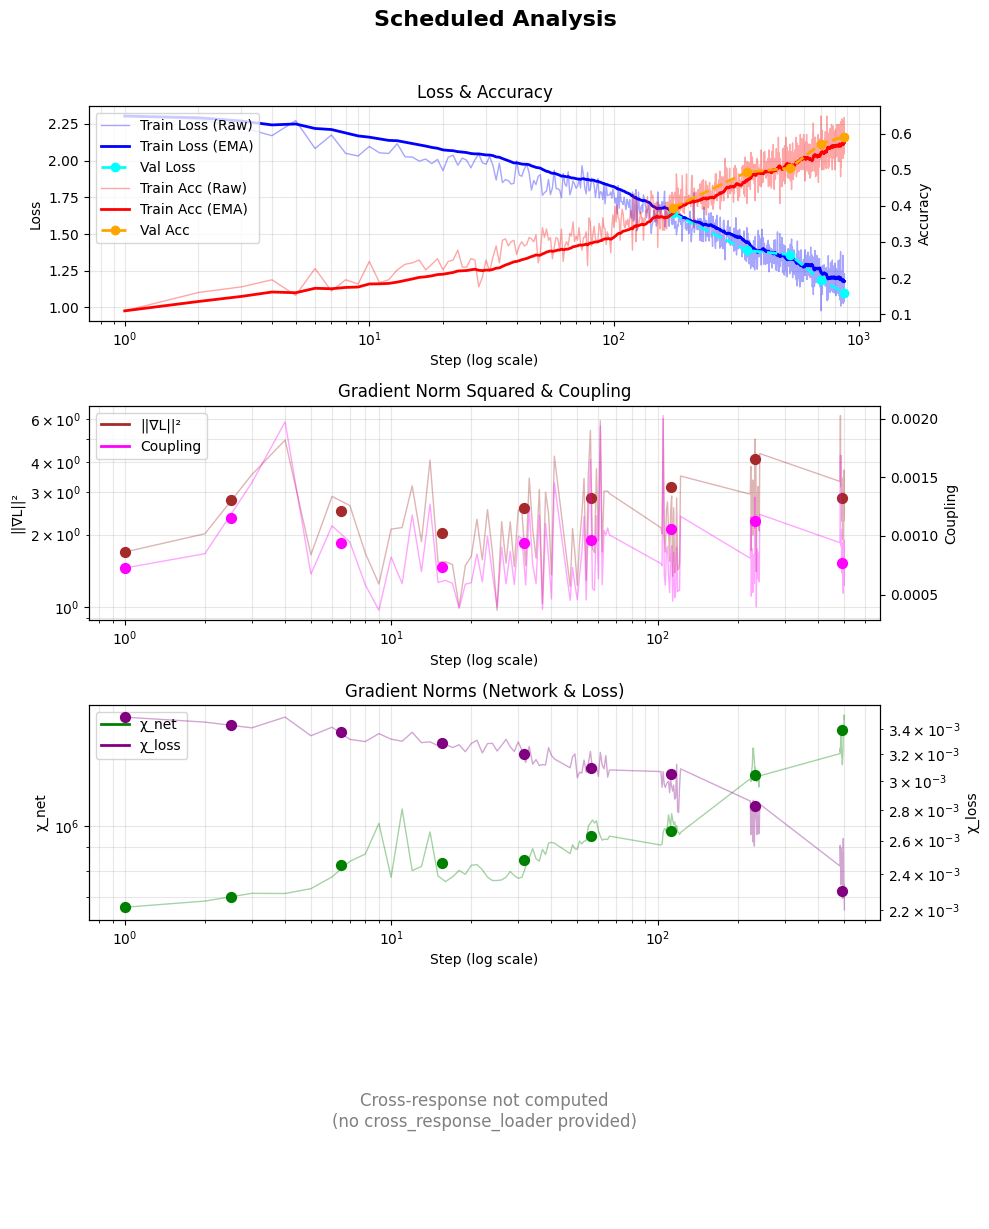

(<Figure size 1000x1200 with 7 Axes>,
 array([<Axes: title={'center': 'Loss & Accuracy'}, xlabel='Step (log scale)', ylabel='Loss'>,
        <Axes: title={'center': 'Gradient Norm Squared & Coupling'}, xlabel='Step (log scale)', ylabel='||∇L||²'>,
        <Axes: title={'center': 'Gradient Norms (Network & Loss)'}, xlabel='Step (log scale)', ylabel='χ_net'>,
        <Axes: >], dtype=object))

In [8]:
plot_scheduler_metrics(f"{trainer.logger.log_dir}/metrics.csv", title="Scheduled Analysis", figsize=(10, 12))